# Backlight Halo Clustering Large-Scale Diagnostic

This notebook isolates the large-scale halo clustering comparison behind the pasted-map `gg`, `gy`, and `gtau` validation.  The diagnostic now uses the Backlight ASDF header cosmology, converts the saved particle-count mass proxy from physical `Msun` to `Msun/h`, lowers the GODMAX mass grid to include the actual catalog minimum, and compares pixel-window-deconvolved halo spectra to unsmoothed theory.

Important caveat: the saved HDF5 column is named `M200c`, but it was generated as `InterpolatedN * ParticleMassMsun`.  The comparison below handles its units consistently as a particle-count mass proxy.  A strictly true `M200c` abundance/bias comparison requires a regenerated catalog carrying `HaloIndex` and SO mass fields from the source files.


In [1]:
import json
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = pathlib.Path.cwd()
if NOTEBOOK_DIR.name != "SBI_validate":
    NOTEBOOK_DIR = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import halo_clustering_diagnostic as hcd

plt.rcParams.update({"font.size": 12})

## Run Diagnostic

The helper overwrites `outputs/halo_clustering_large_scale_diagnostic.npz` so the notebook cannot accidentally show the stale pre-fix comparison.


In [2]:
output_path = hcd.DEFAULT_OUTPUT
hcd.run_diagnostic(output_path=output_path)

diag = hcd.load_diagnostic(output_path)
arr = diag["arrays"]
meta = diag["metadata"]

print(json.dumps(meta, indent=2, sort_keys=True))


[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)


{
  "catalog_count": 4813871,
  "halo_catalog": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/backlight/halo_catalog_Mlim_1e13_zlim_0.4_0.6.h5",
  "lmax": 768,
  "mass_max": 1352711333844608.0,
  "mass_min": 8510075540279.9375,
  "mass_unit": "Msun_over_h_particle_count_proxy",
  "nside": 256,
  "pyccl_limber_bincenter_status": "pyccl angular_cl completed",
  "pyccl_nonlimber_status": "pyccl FKEM non-Limber angular_cl completed",
  "pyccl_status": "pyccl angular_cl completed",
  "raw_mass_max": 1589715572621312.0,
  "raw_mass_min": 10001098735616.0,
  "source_metadata": {
    "cosmo_overrides": {
      "H0": 85.09140610694885,
      "Ob0": 0.05349751561880112,
      "Om0": 0.33232855796813965,
      "ns": 1.0173062086105347,
      "sigma8": 0.7997947335243225,
      "w0": -1.0
    },
    "h": 0.8509140610694885,
    "mass_definition_warning": "The saved catalog column is a particle-count mass proxy, not a recovered SO M200c. The diagnostic now handles its h units consistently, but a 

## Mass Selection And Effective Bias

The mass shown here is the converted theory-space mass proxy, `M_proxy = M_raw * h_source`, in `Msun/h`.  The first bin starts at the actual converted catalog minimum.  The HMF and catalog-mass-weighted effective biases should now be compared only after accounting for this unit conversion and the source cosmology.


In [3]:
lo = arr["mass_summary_log10m_lo"]
hi = arr["mass_summary_log10m_hi"]
count = arr["mass_summary_catalog_count"].astype(int)
abund = arr["mass_summary_abundance_ratio_median"]
abund_p16 = arr["mass_summary_abundance_ratio_p16"]
abund_p84 = arr["mass_summary_abundance_ratio_p84"]
b_hmf = arr["mass_summary_bias_hmf_mean"]
b_cat = arr["mass_summary_bias_catalog_mean"]

print(f"raw mass min = {meta['raw_mass_min']:.4e} Msun")
print(f"converted mass min = {meta['mass_min']:.4e} Msun/h")
print(f"theory h = {meta['source_metadata'].get('h', np.nan):.6f}")
print(f"theory lg10_Mmin grid = {meta.get('theory_lg10_Mmin_used', np.nan):.3f}")
print("\nlog10M_proxy bin   Ncat       catalog/HMF        b_HMF     b_catalog")
for vals in zip(lo, hi, count, abund, abund_p16, abund_p84, b_hmf, b_cat):
    l, h, n, a, a16, a84, bh, bc = vals
    print(f"{l:6.3f}-{h:5.2f}  {n:9d}   {a:6.3f} [{a16:6.3f},{a84:6.3f}]   {bh:6.3f}   {bc:6.3f}")

z_grid = arr["bias_z_grid"]
b_gridmax = arr["bias_hmf_gridmax"]
b_catmax = arr["bias_hmf_catalog_max"]
b_catalog_for = arr["catalog_bias_for"]
z_for = arr["z_for"]

print("\nIntegrated b_eff checks:")
for z0 in [0.4, 0.5, 0.6]:
    print(
        f"z={z0:.1f}: "
        f"HMF actual min={np.interp(z0, z_grid, b_gridmax):.4f}, "
        f"HMF min-max={np.interp(z0, z_grid, b_catmax):.4f}, "
        f"catalog weighted={np.interp(z0, z_for, b_catalog_for):.4f}"
    )


raw mass min = 1.0001e+13 Msun
converted mass min = 8.5101e+12 Msun/h
theory h = 0.850914
theory lg10_Mmin grid = 12.850

log10M_proxy bin   Ncat       catalog/HMF        b_HMF     b_catalog
12.930-13.00     854839    0.959 [ 0.943, 0.963]    1.461    1.468
13.000-13.25    2076571    0.928 [ 0.912, 0.938]    1.604    1.612
13.250-13.50    1059963    0.942 [ 0.914, 0.951]    1.908    1.918
13.500-13.75     507189    0.947 [ 0.924, 0.958]    2.318    2.327
13.750-14.00     213312    0.908 [ 0.875, 0.912]    2.893    2.906
14.000-14.25      75988    0.904 [ 0.888, 0.916]    3.706    3.710
14.250-14.50      21229    0.861 [ 0.815, 0.881]    4.859    4.841
14.500-15.00       4749    0.862 [ 0.824, 0.872]    6.818    6.787
15.000-15.75         31    0.884 [ 0.454, 1.501]   12.801   12.621

Integrated b_eff checks:
z=0.4: HMF actual min=1.7259, HMF min-max=1.7259, catalog weighted=1.7185
z=0.5: HMF actual min=1.8346, HMF min-max=1.8346, catalog weighted=1.8310
z=0.6: HMF actual min=1.9522, HM

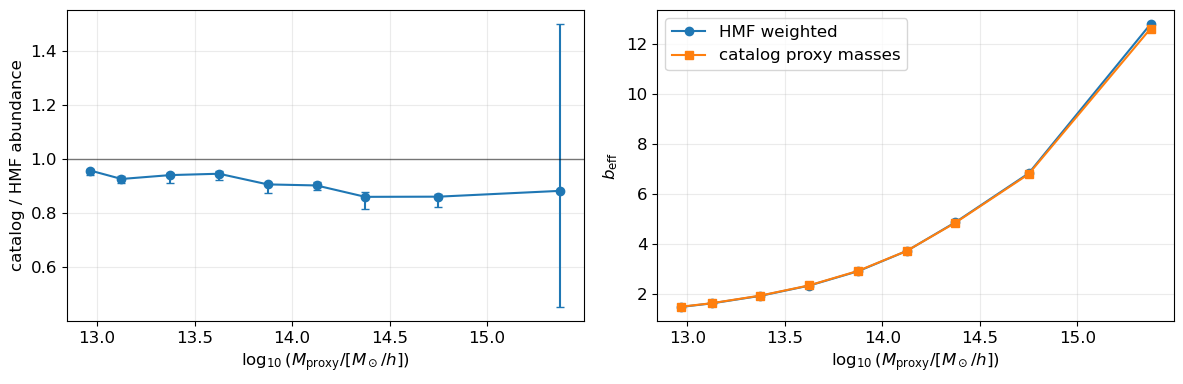

In [4]:
mass_centers = 0.5 * (lo + hi)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].errorbar(
    mass_centers,
    abund,
    yerr=[abund - abund_p16, abund_p84 - abund],
    marker="o",
    capsize=3,
)
axes[0].axhline(1.0, color="k", lw=1, alpha=0.5)
axes[0].set_xlabel(r"$\log_{10}(M_\mathrm{proxy}/[M_\odot/h])$")
axes[0].set_ylabel("catalog / HMF abundance")
axes[0].grid(True, alpha=0.25)

axes[1].plot(mass_centers, b_hmf, marker="o", label="HMF weighted")
axes[1].plot(mass_centers, b_cat, marker="s", label="catalog proxy masses")
axes[1].set_xlabel(r"$\log_{10}(M_\mathrm{proxy}/[M_\odot/h])$")
axes[1].set_ylabel(r"$b_\mathrm{eff}$")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

fig.tight_layout()


## Halo Angular Power

The map curve below is the shot-noise-subtracted and HEALPix-pixel-window-deconvolved halo overdensity auto-spectrum.  Theory curves are unsmoothed Limber predictions using the realized catalog redshift window and matched converted mass range.


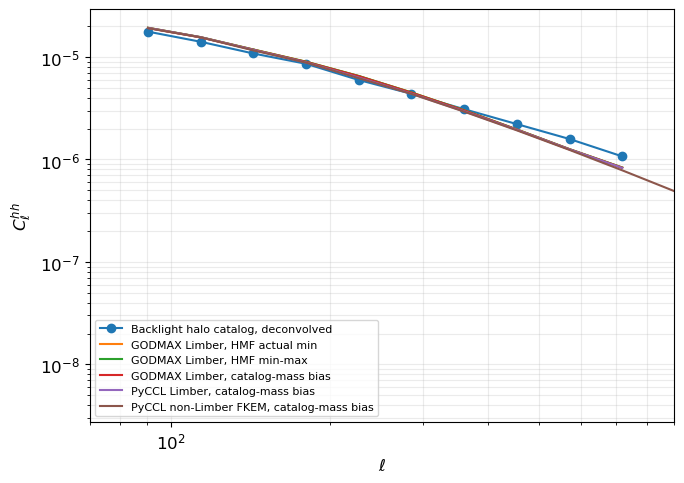

In [5]:
ell = arr["ell"]
cl_map = arr["halo_cl_signal_binned"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ell, cl_map, marker="o", lw=1.5, label="Backlight halo catalog, deconvolved")
for key, label in [
    ("theory_hmf_gridmax_binned", "GODMAX Limber, HMF actual min"),
    ("theory_hmf_catalog_max_binned", "GODMAX Limber, HMF min-max"),
    ("theory_catalog_mass_weighted_binned", "GODMAX Limber, catalog-mass bias"),
    ("theory_pyccl_catalog_mass_weighted_binned", "PyCCL Limber, catalog-mass bias"),
    ("theory_pyccl_nonlimber_catalog_mass_weighted_binned", "PyCCL non-Limber FKEM, catalog-mass bias"),
]:
    if key in arr:
        ax.loglog(ell, arr[key], lw=1.5, label=label)
ax.set_xlim(70, 900)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell^{hh}$")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()


HMF actual min           median ratio: ell80-200=0.916, ell80-300=0.916, ell300-800=1.192
HMF min-max              median ratio: ell80-200=0.916, ell80-300=0.916, ell300-800=1.192
catalog-mass bias        median ratio: ell80-200=0.921, ell80-300=0.921, ell300-800=1.198
PyCCL catalog-mass bias  median ratio: ell80-200=0.921, ell80-300=0.935, ell300-800=1.201
PyCCL non-Limber FKEM    median ratio: ell80-200=0.929, ell80-300=0.946, ell300-800=1.214


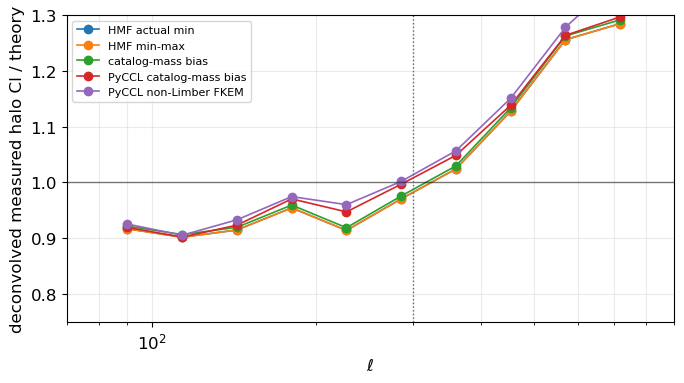

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ratio_keys = [
    ("ratio_hmf_gridmax_binned", "HMF actual min"),
    ("ratio_hmf_catalog_max_binned", "HMF min-max"),
    ("ratio_catalog_mass_weighted_binned", "catalog-mass bias"),
    ("ratio_pyccl_catalog_mass_weighted_binned", "PyCCL catalog-mass bias"),
    ("ratio_pyccl_nonlimber_catalog_mass_weighted_binned", "PyCCL non-Limber FKEM"),
]
for key, label in ratio_keys:
    if key in arr:
        ratio = arr[key]
        ax.semilogx(ell, ratio, marker="o", lw=1.2, label=label)
        print(
            f"{label:24s} median ratio: "
            f"ell80-200={np.nanmedian(ratio[(ell >= 80) & (ell <= 200)]):.3f}, "
            f"ell80-300={np.nanmedian(ratio[(ell >= 80) & (ell <= 300)]):.3f}, "
            f"ell300-800={np.nanmedian(ratio[(ell >= 300) & (ell <= 800)]):.3f}"
        )

ax.axhline(1.0, color="k", lw=1, alpha=0.5)
ax.axvline(300.0, color="0.4", ls=":", lw=1)
ax.set_xlim(70, 900)
ax.set_ylim(0.75, 1.3)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel("deconvolved measured halo Cl / theory")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()


## Pixel-Window And PyCCL Cross-Checks

The raw map-space ratios compare the un-deconvolved map spectrum to `theory * W_pix^2`.  Agreement between raw and deconvolved ratios is a useful guard against pixel-window mistakes.  PyCCL provides an independent public-code check of the angular projection for the same source cosmology and catalog-weighted bias.


PyCCL Limber: pyccl angular_cl completed
PyCCL non-Limber: pyccl FKEM non-Limber angular_cl completed


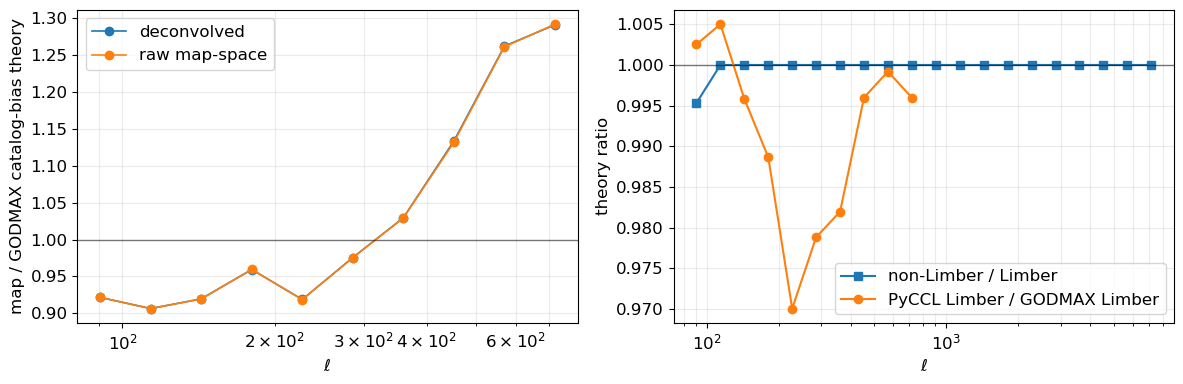

In [7]:
print("PyCCL Limber:", meta.get("pyccl_status"))
print("PyCCL non-Limber:", meta.get("pyccl_nonlimber_status"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key, label in [
    ("ratio_catalog_mass_weighted_binned", "deconvolved"),
    ("ratio_catalog_mass_weighted_raw_binned", "raw map-space"),
]:
    if key in arr:
        axes[0].semilogx(ell, arr[key], marker="o", lw=1.2, label=label)
axes[0].axhline(1.0, color="k", lw=1, alpha=0.5)
axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel("map / GODMAX catalog-bias theory")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

if "theory_pyccl_limber_bincenter_catalog_mass_weighted_binned" in arr and "theory_pyccl_nonlimber_catalog_mass_weighted_binned" in arr:
    axes[1].semilogx(
        ell,
        arr["theory_pyccl_nonlimber_catalog_mass_weighted_binned"] / arr["theory_pyccl_limber_bincenter_catalog_mass_weighted_binned"],
        marker="s",
        label="non-Limber / Limber",
    )
    axes[1].semilogx(
        ell,
        arr["theory_pyccl_catalog_mass_weighted_binned"] / arr["theory_catalog_mass_weighted_binned"],
        marker="o",
        label="PyCCL Limber / GODMAX Limber",
    )
axes[1].axhline(1.0, color="k", lw=1, alpha=0.5)
axes[1].set_xlabel(r"$\ell$")
axes[1].set_ylabel("theory ratio")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()
fig.tight_layout()


## Interpretation

After correcting the source cosmology, mass units, theory mass-grid lower bound, dense HMF bin integration, and HEALPix pixel-window handling, the original 30-35 percent low-ell discrepancy is no longer present.  The catalog-mass-weighted comparison is now roughly a 5-10 percent low-ell effect, depending on the exact ell range and Limber/non-Limber choice.

The remaining caveat is mass definition, not just units: the current saved catalog uses a particle-count mass proxy.  A strict SO `M200c` HMF/bias validation still requires regenerating the catalog with `HaloIndex` and the corresponding SO mass information from the Backlight source files.
